In [ ]:
# 既にインストールされていれば不要
!pip install quri-parts
!pip install "quri-parts[qulacs]"

In [2]:
import numpy as np
from numpy.linalg import eigh
from quri_parts.core.operator import Operator, pauli_label
from quri_parts.core.operator import get_sparse_matrix

# 参考文献の表1 から, 水素分子のハミルトニアンを定義する
g_list = np.array([0.3593, 0.0896, -0.4826, 0.0896])
pauli_strings = ['Z0', 'Y0 Y1', 'Z1', 'X0 X1']
ham = Operator({pauli_label(p): g for g, p in zip(g_list, pauli_strings)})
print(ham)

# 厳密な基底状態エネルギーを求める
ham_sparse_mat = get_sparse_matrix(ham)
eigvals, _ = eigh(ham_sparse_mat.toarray())
e_exact = eigvals[0]
print("H_eff の固有値:", eigvals)
print("厳密な基底状態エネルギー:", e_exact)

0.3593*Z0 + 0.0896*Y0 Y1 + -0.4826*Z1 + 0.0896*X0 X1
H_eff の固有値: [-0.86076027 -0.1233      0.1233      0.86076027]
厳密な基底状態エネルギー: -0.8607602744086184


In [3]:
from scipy.linalg import expm
from numpy.linalg import matrix_power, eig

n_qubits = 2

def order_n_trotter_approx(hamiltonian, t, n_trotter_steps):
    """ トロッター分解による近似を用いてハミルトニアンの時間発展演算子の行列表示を計算する
    """
    matrix = np.eye(2**n_qubits) # 単位行列
    # 1 トロッターステップを計算
    for pauli, g in hamiltonian.items(): # パウリ行列と係数の組を取得
        exponent = get_sparse_matrix(pauli, n_qubits).toarray()
        matrix = matrix @ expm(-1j * t / n_trotter_steps * g * exponent)

    # (1 トロッターステップ)^{n_trotter_steps}
    matrix = matrix_power(matrix, n_trotter_steps)
    return matrix

# トロッター分解による近似を用いて基底状態エネルギーを求める
tau = 0.64 # 時間発展の時間(参考文献の表1から)
print('N, E_trot, |E_exact - E_trot|')
for n in range(1, 10, 2):
    U_trot = order_n_trotter_approx(ham, tau, n)
    # U_trotの固有値を計算してハミルトニアンの基底状態エネルギーに変換する
    vals, vecs = eig(U_trot)
    eigs_trotter = - np.angle(vals)/tau # U=exp(-iH*tau) なのでマイナス
    e_trotter = np.sort(eigs_trotter)[0]
    print( f"{n}, {e_trotter:.10f}, {abs(e_exact - e_trotter):.3e}" )

N, E_trot, |E_exact - E_trot|
1, -0.8602760326, 4.842e-04
3, -0.8607068561, 5.342e-05
5, -0.8607410548, 1.922e-05
7, -0.8607504700, 9.804e-06
9, -0.8607543437, 5.931e-06


In [4]:
from quri_parts.circuit import QuantumCircuit
def controlled_U_circuit(g_list, tau, k, n_trotter_steps) -> QuantumCircuit:
    """
    ハミルトニアンの形を仮定して，
    反復的量子位相推定の制御時間発展演算子controlled-U^{2^{k-1}}を実装する．
    g_list: 順にZ0, Y0Y1, Z1, X0X1 に対応するハミルトニアンの係数
    """
    n_qubits = 3 # 全体では3量子ビット
    a_idx = 2 # 補助ビットのインデックス

    # controlled-exp(-i*phi[0]*Z0) などを実装していく
    phi = tau / n_trotter_steps * g_list

    # 今回は愚直に2^{k-1}回の時間発展を繰り返す
    circuit = QuantumCircuit(n_qubits)

    for _ in range( 2 ** (k-1) ):
        # U = exp(-i*H*tau) をトロッター分解で近似して実装
        # qp のパウリ回転ゲートはRZ(theta) = e^{-i*theta/2*Z} といった定義
        # よってexp(-i*phi[0]*Z) = RZ(2*theta)
        for _ in range(n_trotter_steps):
            # controlled exp(-i*phi[0]*Z0)
            circuit.add_RZ_gate(0, phi[0])
            circuit.add_CNOT_gate(a_idx, 0)
            circuit.add_RZ_gate(0, -phi[0])
            circuit.add_CNOT_gate(a_idx, 0)

            # controlled exp(-i*phi[1]*Y0 Y1)
            circuit.add_Sdag_gate(0)
            circuit.add_Sdag_gate(1)
            circuit.add_H_gate(0)
            circuit.add_H_gate(1)
            circuit.add_CNOT_gate(0, 1)
            circuit.add_RZ_gate(1, phi[1])
            circuit.add_CNOT_gate(a_idx, 1)
            circuit.add_RZ_gate(1, -phi[1])
            circuit.add_CNOT_gate(a_idx, 1)
            circuit.add_CNOT_gate(0, 1)
            circuit.add_H_gate(0)
            circuit.add_H_gate(1)
            circuit.add_S_gate(0)
            circuit.add_S_gate(1)

            # controlled exp(-i*phi[2]*Z1)
            circuit.add_RZ_gate(1, phi[2])
            circuit.add_CNOT_gate(a_idx, 1)
            circuit.add_RZ_gate(1, -phi[2])
            circuit.add_CNOT_gate(a_idx, 1)
            # controlled exp(-i*phi[3]*X0 X1)
            circuit.add_H_gate(0)
            circuit.add_H_gate(1)
            circuit.add_CNOT_gate(0, 1)
            circuit.add_RZ_gate(1, phi[3])
            circuit.add_CNOT_gate(a_idx, 1)
            circuit.add_RZ_gate(1, -phi[3])
            circuit.add_CNOT_gate(a_idx, 1)
            circuit.add_CNOT_gate(0, 1)
            circuit.add_H_gate(0)
            circuit.add_H_gate(1)

    return circuit

In [5]:
def IQPE_circuit(g_list, tau, accumulated_phase, k, n_trotter_steps) -> QuantumCircuit:
    n_qubits = 3 # 全体では3量子ビット
    a_idx = 2 # 補助ビットのインデックス

    circuit = QuantumCircuit(n_qubits, cbit_count=1)
    circuit.add_H_gate(a_idx)
    # 蓄積位相を付与
    circuit.add_RZ_gate(a_idx, -accumulated_phase)
    # controlled-U^{2^{k-1}}を実装
    circuit.extend(controlled_U_circuit(g_list, tau, k, n_trotter_steps))
    circuit.add_H_gate(a_idx)
    return circuit

書籍版のコードではエラーが発生するため、`n_trotter_step`をキーワード引数から位置引数に変更しています。

In [6]:
from quri_parts.core.state import GeneralCircuitQuantumState
from quri_parts.qulacs.simulator import evaluate_state_to_vector, get_marginal_probability

def iterative_phase_estimation(
    g_list: list[float],
    tau: float,
    n_itter: int,
    init_state: GeneralCircuitQuantumState,
    n_trotter_step,
    kickback_phase=0.0
) -> float:
    for k in reversed(range(1, n_itter+1)): # n_itterから1まで実行
        circuit = IQPE_circuit(
            np.array(g_list).real,
            tau,
            kickback_phase,
            k,
            n_trotter_step # 修正
            )

        # 回路を実行
        psi = evaluate_state_to_vector(init_state.with_gates_applied(circuit)).vector

        # 部分トレース(マージナル確率を取得)
        p0 = get_marginal_probability(psi, {2: 0})
        p1 = get_marginal_probability(psi, {2: 1})
        # print(f" k={k:2d}, p0={p0:.3f}, p1={p1:.3f}")

        # kickback位相を更新
        kth_digit = 1 if (p0 < p1) else 0
        kickback_phase = 0.5 * kickback_phase + np.pi * 0.5 * kth_digit
    return 2 * kickback_phase

In [7]:
from quri_parts.core.state import quantum_state
n_qubits = 3
hf_state = quantum_state(n_qubits, bits=0b01) # 入力状態
n_trotter_steps = 1

# トロッター分解した場合の基底状態エネルギーを計算
# これをIQPE 結果の厳密な値とみなす
U_trot = order_n_trotter_approx(ham, tau, n_trotter_steps)
vals, vecs = eig(U_trot)
eigs_trotter = - np.angle(vals)/tau # U = exp(-iH*tau)なのでマイナスをつける
e_trotter = np.sort(eigs_trotter)[0]
print(f"e_trotter={e_trotter:.10f}")

result_list = []
for n_iter in range(1, 12+1): # 何桁まで計算するか
    iqpe_phase = iterative_phase_estimation(g_list, tau, n_iter, hf_state, n_trotter_steps)
    e_iqpe = - iqpe_phase / tau
    diff = np.abs(e_iqpe-e_trotter)
    print(f"n_iter={n_iter:2d}, e_iqpe={e_iqpe:6f}, error={diff:.3e}")
    result_list.append([n_iter, e_iqpe])

e_trotter=-0.8602760326
n_iter= 1, e_iqpe=-0.000000, error=8.603e-01
n_iter= 2, e_iqpe=-0.000000, error=8.603e-01
n_iter= 3, e_iqpe=-1.227185, error=3.669e-01
n_iter= 4, e_iqpe=-0.613592, error=2.467e-01
n_iter= 5, e_iqpe=-0.920388, error=6.011e-02
n_iter= 6, e_iqpe=-0.920388, error=6.011e-02
n_iter= 7, e_iqpe=-0.843689, error=1.659e-02
n_iter= 8, e_iqpe=-0.843689, error=1.659e-02
n_iter= 9, e_iqpe=-0.862864, error=2.588e-03
n_iter=10, e_iqpe=-0.862864, error=2.588e-03
n_iter=11, e_iqpe=-0.858071, error=2.206e-03
n_iter=12, e_iqpe=-0.860467, error=1.913e-04


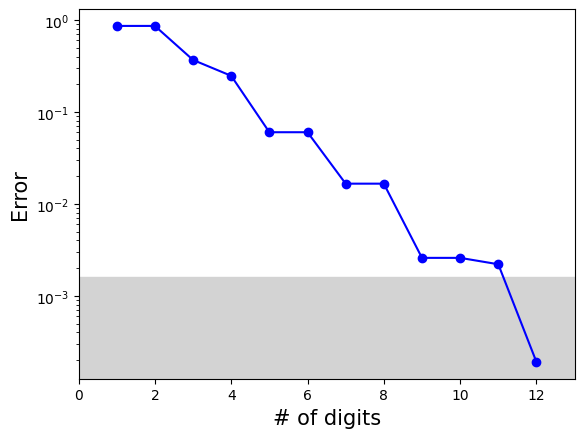

In [8]:
import matplotlib.pyplot as plt
result_array = np.array(result_list)
plt.xlabel("# of digits", fontsize=15)
plt.ylabel("Error", fontsize=15)
plt.semilogy(result_array[:,0], np.abs(result_array[:,1] - e_trotter), "bo-")
plt.xlim(0,13)
plt.fill_between([0,13], 1.6e-3, color = "lightgrey") # 化学精度の領域
plt.show()